In [1]:

!pip install tensorflow_addons

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
!pip install git+https://github.com/openai/CLIP.git

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-bbgzfs5e
  Running command git clone -q https://github.com/openai/CLIP.git /tmp/pip-req-build-bbgzfs5e


## Importing transformers

In [3]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [4]:
#from tensorflow.python.ops.numpy_ops import np_config
#np_config.enable_numpy_behavior()

In [5]:
from transformers import AutoTokenizer, AutoModel,pipeline
summarize = pipeline("summarization", model = "facebook/bart-large")
def BART_t2t(text):
 return summarize(text, min_length = 3,max_length = 20, do_sample = False)
print(BART_t2t("BART model pre-trained on English language. It was introduced in the paper BART: Denoising Sequence-to-Sequence Pre-training for Natural Language Generation, Translation, and Comprehension by Lewis et al. and first released in this repository.")[0])

{'summary_text': 'BART model pre-trained on English language. It was introduced in the paper BART'}


In [64]:
from transformers import BartTokenizer, BartModel
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large")
model = BartModel.from_pretrained('facebook/bart-large')
def BART_pl(text):

  text = BART_t2t(text)[0]['summary_text']
  inputs = tokenizer(text, return_tensors="pt")
  a =  model(**inputs)
  return a


In [65]:
a = BART_pl('a')

Your max_length is set to 20, but you input_length is only 3. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=1)


In [66]:
a

Seq2SeqModelOutput([('last_hidden_state',
                     tensor([[[ 0.8850,  0.2853, -0.2070,  ...,  1.6245, -0.2297,  0.2214],
                              [ 0.8850,  0.2853, -0.2070,  ...,  1.6245, -0.2297,  0.2214],
                              [-0.3311,  2.6995, -1.7593,  ...,  0.1177,  0.4932,  0.9504]]],
                            grad_fn=<NativeLayerNormBackward0>)),
                    ('past_key_values',
                     ((tensor([[[[ 0.2741,  0.4615,  1.9901,  ...,  0.9927,  2.8700, -1.3778],
                                 [-0.0745,  0.6451,  1.7084,  ...,  0.9115,  2.5264, -1.6802],
                                 [-2.8132, -0.0346, -2.2063,  ..., -2.6824, -3.9180, -1.2120]],
                       
                                [[-2.3304, -2.3024, -0.2321,  ..., -0.7134, -0.0767,  0.9481],
                                 [-1.8701, -2.2585, -0.1146,  ..., -1.3593, -0.1351,  0.1502],
                                 [ 0.5163, -0.0266,  0.4974,  ..., -1.2435

In [7]:
from transformers import CLIPProcessor, TFCLIPModel
#model_clip = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
#processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [8]:
import numpy as np
from sklearn.decomposition import PCA
import subprocess
pca =  PCA(n_components = 3)
def reduce_channels(encoding): #dimensionality reduction using PCA and mean correction
 array = encoding.detach().cpu().numpy().reshape(-1,1024).T
 X_new = array - np.mean(array)
 return pca.fit_transform(X_new)
    

In [9]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from enum import Enum
from glob import glob
from functools import partial

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow_addons.layers import InstanceNormalization

import gdown
from zipfile import ZipFile

In [10]:
import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder-large/5")
embeddings = embed([
    "The quick brown fox jumps over the lazy dog.",
    "I am a sentence for which I would like to get its embedding"])

print(embeddings)

tf.Tensor(
[[ 0.01305106  0.0223512  -0.03263272 ... -0.00565094 -0.04793027
  -0.11492757]
 [ 0.05833391 -0.08185011  0.06890939 ... -0.00923876 -0.08695352
  -0.01415742]], shape=(2, 512), dtype=float32)


In [11]:
def text2PCA(word):
  a = tf.transpose(reduce_channels(BART_pl(word)[0]))
  return tf.reshape(a, [6, 512])


In [12]:
text2PCA("This is a try for many words in the sequece").shape

Your max_length is set to 20, but you input_length is only 14. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)


TensorShape([6, 512])

## Input pipeline for the text

In [13]:
tf_hub_embedding_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        trainable=False,
                                        name="universal_sentence_encoder")

In [14]:
inputs = layers.Input(shape=[], dtype=tf.string)
pretrained_embeddings = tf_hub_embedding_layer(inputs)
dense = tf.keras.layers.Dense(512, activation = "linear")(pretrained_embeddings)
TEXT_PREP = tf.keras.Model(inputs, dense)

In [15]:
try_output = TEXT_PREP(tf.constant(["This is a try for many words in the sequece"]))
try_output.shape

TensorShape([1, 512])

### Load in the datasets

## Custom Layers

In [16]:
def fade_in(alpha, a, b):
    return alpha * a + (1.0 - alpha) * b


def wasserstein_loss(y_true, y_pred):
    return -tf.reduce_mean(y_true * y_pred)


def pixel_norm(x, epsilon=1e-8):
    return x / tf.math.sqrt(tf.reduce_mean(x**2, axis=-1, keepdims=True) + epsilon)


def minibatch_std(input_tensor, epsilon=1e-8):
    n, h, w, c = tf.shape(input_tensor)
    group_size = tf.minimum(4, n)
    x = tf.reshape(input_tensor, [group_size, -1, h, w, c])
    group_mean, group_var = tf.nn.moments(x, axes=(0), keepdims=False)
    group_std = tf.sqrt(group_var + epsilon)
    avg_std = tf.reduce_mean(group_std, axis=[1, 2, 3], keepdims=True)
    x = tf.tile(avg_std, [group_size, h, w, 1])
    return tf.concat([input_tensor, x], axis=-1)


class EqualizedConv(layers.Layer):
    def __init__(self, out_channels, kernel=3, gain=2, **kwargs):
        super(EqualizedConv, self).__init__(**kwargs)
        self.kernel = kernel
        self.out_channels = out_channels
        self.gain = gain
        self.pad = kernel != 1

    def build(self, input_shape):
        self.in_channels = input_shape[-1]
        initializer = keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
        self.w = self.add_weight(
            shape=[self.kernel, self.kernel, self.in_channels, self.out_channels],
            initializer=initializer,
            trainable=True,
            name="kernel",
        )
        self.b = self.add_weight(
            shape=(self.out_channels,), initializer="zeros", trainable=True, name="bias"
        )
        fan_in = self.kernel * self.kernel * self.in_channels
        self.scale = tf.sqrt(self.gain / fan_in)

    def call(self, inputs):
        if self.pad:
            x = tf.pad(inputs, [[0, 0], [1, 1], [1, 1], [0, 0]], mode="REFLECT")
        else:
            x = inputs
        output = (
            tf.nn.conv2d(x, self.scale * self.w, strides=1, padding="VALID") + self.b
        )
        return output


class EqualizedDense(layers.Layer):
    def __init__(self, units, gain=2, learning_rate_multiplier=1, **kwargs):
        super(EqualizedDense, self).__init__(**kwargs)
        self.units = units
        self.gain = gain
        self.learning_rate_multiplier = learning_rate_multiplier

    def build(self, input_shape):
        self.in_channels = input_shape[-1]
        initializer = keras.initializers.RandomNormal(
            mean=0.0, stddev=1.0 / self.learning_rate_multiplier
        )
        self.w = self.add_weight(
            shape=[self.in_channels, self.units],
            initializer=initializer,
            trainable=True,
            name="kernel",
        )
        self.b = self.add_weight(
            shape=(self.units,), initializer="zeros", trainable=True, name="bias"
        )
        fan_in = self.in_channels
        self.scale = tf.sqrt(self.gain / fan_in)

    def call(self, inputs):
        output = tf.add(tf.matmul(inputs, self.scale * self.w), self.b)
        return output * self.learning_rate_multiplier


class AddNoise(layers.Layer):
    def build(self, input_shape):
        n, h, w, c = input_shape[0]
        initializer = keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
        self.b = self.add_weight(
            shape=[1, 1, 1, c], initializer=initializer, trainable=True, name="kernel"
        )

    def call(self, inputs):
        x, noise = inputs
        output = x + self.b * noise
        return output


class AdaIN(layers.Layer):
    def __init__(self, gain=1, **kwargs):
        super(AdaIN, self).__init__(**kwargs)
        self.gain = gain

    def build(self, input_shapes):
        x_shape = input_shapes[0]
        w_shape = input_shapes[1]

        self.w_channels = w_shape[-1]
        self.x_channels = x_shape[-1]

        self.dense_1 = EqualizedDense(self.x_channels, gain=1)
        self.dense_2 = EqualizedDense(self.x_channels, gain=1)

    def call(self, inputs):
        x, w = inputs
        ys = tf.reshape(self.dense_1(w), (-1, 1, 1, self.x_channels))
        yb = tf.reshape(self.dense_2(w), (-1, 1, 1, self.x_channels))
        return ys * x + yb

In [17]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [18]:
from transformers import BartTokenizer, BartModel
from transformers import CLIPProcessor, CLIPModel

In [61]:
import torch
from clip import *
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess_clip = clip.load("ViT-B/32", device=device)


def L_clip(Xt,Yi): #Xt is a string array, Yi is an image array (both tensorflow)
 Xt = clip.tokenize(Xt).to(device)
 Yi = preprocess_clip(Image.fromarray(Yi.eval(session=tf.compat.v1.Session()))).unsqueeze(0).to(device)
 with torch.no_grad():
    logits_per_image, logits_per_text = model(Yi, Xt)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
 return 1- probs

In [59]:
clip.tokenize('penis').to(device)

tensor([[49406,  1501,   533, 49407,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], device='cuda:0',
       dtype=torch.int32)

In [60]:
clip.load("ViT-B/32", device=device)

(CLIP(
   (visual): VisionTransformer(
     (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
     (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
     (transformer): Transformer(
       (resblocks): Sequential(
         (0): ResidualAttentionBlock(
           (attn): MultiheadAttention(
             (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
           )
           (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
           (mlp): Sequential(
             (c_fc): Linear(in_features=768, out_features=3072, bias=True)
             (gelu): QuickGELU()
             (c_proj): Linear(in_features=3072, out_features=768, bias=True)
           )
           (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         )
         (1): ResidualAttentionBlock(
           (attn): MultiheadAttention(
             (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, 

In [20]:
!pip install -r /content/CLIP/requirements.txt

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [21]:
def Mapping(num_stages, input_shape=512):
    z = layers.Input(shape=(input_shape))
    w = pixel_norm(z)
    for i in range(8):
        w = EqualizedDense(512, learning_rate_multiplier=0.01)(w)
        w = layers.LeakyReLU(0.2)(w)
    w = tf.tile(tf.expand_dims(w, 1), (1, num_stages, 1))
    #print(f"mapping output shape: {w.shape}")
    return keras.Model(z, w, name="mapping")


class Generator:
    def __init__(self, start_res_log2, target_res_log2):
        self.start_res_log2 = start_res_log2
        self.target_res_log2 = target_res_log2
        self.num_stages = target_res_log2 - start_res_log2 + 1
        # list of generator blocks at increasing resolution
        self.g_blocks = []
        # list of layers to convert g_block activation to RGB
        self.to_rgb = []
        # list of noise input of different resolutions into g_blocks
        self.noise_inputs = []
        # filter size to use at each stage, keys are log2(resolution)
        self.filter_nums = {
            0: 512,
            1: 512,
            2: 512,  # 4x4
            3: 512,  # 8x8
            4: 512,  # 16x16
            5: 512,  # 32x32
            6: 256,  # 64x64
            7: 128,  # 128x128
            8: 64,  # 256x256
            9: 32,  # 512x512
            10: 16,
        }  # 1024x1024

        start_res = 2 ** start_res_log2
        self.input_shape = (start_res, start_res, self.filter_nums[start_res_log2])
        self.g_input = layers.Input(self.input_shape, name="generator_input")

        for i in range(start_res_log2, target_res_log2 + 1):
            filter_num = self.filter_nums[i]
            res = 2 ** i
            self.noise_inputs.append(
                layers.Input(shape=(res, res, 1), name=f"noise_{res}x{res}")
            )
            to_rgb = Sequential(
                [
                    layers.InputLayer(input_shape=(res, res, filter_num)),
                    EqualizedConv(3, 1, gain=1),
                ],
                name=f"to_rgb_{res}x{res}",
            )
            self.to_rgb.append(to_rgb)
            is_base = i == self.start_res_log2
            if is_base:
                input_shape = (res, res, self.filter_nums[i - 1])
            else:
                input_shape = (2 ** (i - 1), 2 ** (i - 1), self.filter_nums[i - 1])
            g_block = self.build_block(
                filter_num, res=res, input_shape=input_shape, is_base=is_base
            )
            self.g_blocks.append(g_block)

    def build_block(self, filter_num, res, input_shape, is_base):
        input_tensor = layers.Input(shape=input_shape, name=f"g_{res}")
        noise = layers.Input(shape=(res, res, 1), name=f"noise_{res}")
        w = layers.Input(shape=512)
        ## v: text input to the generator
        v = layers.Input(shape=512)
        x = input_tensor

        if not is_base:
            x = layers.UpSampling2D((2, 2))(x)
            x = EqualizedConv(filter_num, 3)(x)

        x = AddNoise()([x, noise])
        print(f"Before adding text: x: {x.shape}, w: {w.shape}")
        x = layers.LeakyReLU(0.2)(x)
        x = InstanceNormalization()(x)
        x = AdaIN()([x, w])
        print("First AdaIN works!")
        print(f"After adding: {x.shape}")

        ## Added code block
        print(f"Before adding text: x: {x.shape}, v: {v.shape}")
        x = AdaIN()([x, v])
        print("Second AdaIN works!")
        print(f"After adding: {x.shape}")

        x = EqualizedConv(filter_num, 3)(x)
        x = AddNoise()([x, noise])
        x = layers.LeakyReLU(0.2)(x)
        x = InstanceNormalization()(x)
        x = AdaIN()([x, w])
        print("Third AdaIN works!")
        x = AdaIN()([x, v])
        print("Fourth AdaIN works!")
        return keras.Model([input_tensor, w, noise, v], x, name=f"genblock_{res}x{res}")

    def grow(self, res_log2):
        res = 2 ** res_log2

        num_stages = res_log2 - self.start_res_log2 + 1
        w = layers.Input(shape=(self.num_stages, 512), name="w")
        v = layers.Input(shape=(self.num_stages, 512), name = "v")
        alpha = layers.Input(shape=(1), name="g_alpha")
        x = self.g_blocks[0]([self.g_input, w[:, 0], self.noise_inputs[0], v[:, 0]])

        if num_stages == 1:
            rgb = self.to_rgb[0](x)
        else:
            for i in range(1, num_stages - 1):

                x = self.g_blocks[i]([x, w[:, i], self.noise_inputs[i], v[:, i]])

            old_rgb = self.to_rgb[num_stages - 2](x)
            old_rgb = layers.UpSampling2D((2, 2))(old_rgb)

            i = num_stages - 1
            x = self.g_blocks[i]([x, w[:, i], self.noise_inputs[i], v[:, i]])

            new_rgb = self.to_rgb[i](x)

            rgb = fade_in(alpha[0], new_rgb, old_rgb)

        return keras.Model(
            [self.g_input, w, self.noise_inputs, alpha, v],
            rgb,
            name=f"generator_{res}_x_{res}",
        )


class Discriminator:
    def __init__(self, start_res_log2, target_res_log2):
        self.start_res_log2 = start_res_log2
        self.target_res_log2 = target_res_log2
        self.num_stages = target_res_log2 - start_res_log2 + 1
        # filter size to use at each stage, keys are log2(resolution)
        self.filter_nums = {
            0: 512,
            1: 512,
            2: 512,  # 4x4
            3: 512,  # 8x8
            4: 512,  # 16x16
            5: 512,  # 32x32
            6: 256,  # 64x64
            7: 128,  # 128x128
            8: 64,  # 256x256
            9: 32,  # 512x512
            10: 16,
        }  # 1024x1024
        # list of discriminator blocks at increasing resolution
        self.d_blocks = []
        # list of layers to convert RGB into activation for d_blocks inputs
        self.from_rgb = []

        for res_log2 in range(self.start_res_log2, self.target_res_log2 + 1):
            res = 2 ** res_log2
            filter_num = self.filter_nums[res_log2]
            from_rgb = Sequential(
                [
                    layers.InputLayer(
                        input_shape=(res, res, 3), name=f"from_rgb_input_{res}"
                    ),
                    EqualizedConv(filter_num, 1),
                    layers.LeakyReLU(0.2),
                ],
                name=f"from_rgb_{res}",
            )

            self.from_rgb.append(from_rgb)

            input_shape = (res, res, filter_num)
            if len(self.d_blocks) == 0:
                d_block = self.build_base(filter_num, res)
            else:
                d_block = self.build_block(
                    filter_num, self.filter_nums[res_log2 - 1], res
                )

            self.d_blocks.append(d_block)

    def build_base(self, filter_num, res):
        input_tensor = layers.Input(shape=(res, res, filter_num), name=f"d_{res}")
        x = minibatch_std(input_tensor)
        x = EqualizedConv(filter_num, 3)(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Flatten()(x)
        x = EqualizedDense(filter_num)(x)
        x = layers.LeakyReLU(0.2)(x)
        x = EqualizedDense(1)(x)
        return keras.Model(input_tensor, x, name=f"d_{res}")

    def build_block(self, filter_num_1, filter_num_2, res):
        input_tensor = layers.Input(shape=(res, res, filter_num_1), name=f"d_{res}")
        x = EqualizedConv(filter_num_1, 3)(input_tensor)
        x = layers.LeakyReLU(0.2)(x)
        x = EqualizedConv(filter_num_2)(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.AveragePooling2D((2, 2))(x)
        return keras.Model(input_tensor, x, name=f"d_{res}")

    def grow(self, res_log2):
        res = 2 ** res_log2
        idx = res_log2 - self.start_res_log2
        alpha = layers.Input(shape=(1), name="d_alpha")
        input_image = layers.Input(shape=(res, res, 3), name="input_image")
        x = self.from_rgb[idx](input_image)
        x = self.d_blocks[idx](x)
        if idx > 0:
            idx -= 1
            downsized_image = layers.AveragePooling2D((2, 2))(input_image)
            y = self.from_rgb[idx](downsized_image)
            x = fade_in(alpha[0], x, y)

            for i in range(idx, -1, -1):
                x = self.d_blocks[i](x)
        return keras.Model([input_image, alpha], x, name=f"discriminator_{res}_x_{res}")

In [22]:
def log2(x):
    return int(np.log2(x))

In [23]:
LOSS = []

In [24]:
class StyleGAN(tf.keras.Model):
    def __init__(self, z_dim=512, target_res=64, start_res=4):
        super(StyleGAN, self).__init__()
        self.z_dim = z_dim

        self.target_res_log2 = log2(target_res)
        self.start_res_log2 = log2(start_res)
        self.current_res_log2 = self.target_res_log2
        self.num_stages = self.target_res_log2 - self.start_res_log2 + 1

        self.alpha = tf.Variable(1.0, dtype=tf.float32, trainable=False, name="alpha")

        self.mapping = Mapping(num_stages=self.num_stages)
        self.d_builder = Discriminator(self.start_res_log2, self.target_res_log2)
        self.g_builder = Generator(self.start_res_log2, self.target_res_log2)
        self.g_input_shape = self.g_builder.input_shape

        self.phase = None
        self.train_step_counter = tf.Variable(0, dtype=tf.int32, trainable=False)

        self.loss_weights = {"gradient_penalty": 10, "drift": 0.001}

    def grow_model(self, res):
        tf.keras.backend.clear_session()
        res_log2 = log2(res)
        self.generator = self.g_builder.grow(res_log2)
        self.discriminator = self.d_builder.grow(res_log2)
        self.current_res_log2 = res_log2
        print(f"\nModel resolution:{res}x{res}")

    def compile(
        self, steps_per_epoch, phase, res, d_optimizer, g_optimizer, *args, **kwargs
    ):
        self.loss_weights = kwargs.pop("loss_weights", self.loss_weights)
        self.steps_per_epoch = steps_per_epoch
        if res != 2 ** self.current_res_log2:
            self.grow_model(res)
            self.d_optimizer = d_optimizer
            self.g_optimizer = g_optimizer

        self.train_step_counter.assign(0)
        self.phase = phase
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")
        super(StyleGAN, self).compile(*args, **kwargs)

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def generate_noise(self, batch_size):
        noise = [
            tf.random.normal((batch_size, 2 ** res, 2 ** res, 1))
            for res in range(self.start_res_log2, self.target_res_log2 + 1)
        ]
        return noise

    def gradient_loss(self, grad):
        loss = tf.square(grad)
        loss = tf.reduce_sum(loss, axis=tf.range(1, tf.size(tf.shape(loss))))
        loss = tf.sqrt(loss)
        loss = tf.reduce_mean(tf.square(loss - 1))
        return loss

    def img_to_numpy(img):
      pass

    def train_step(self, data):
        real_images, real_text = data
        print(f"real_text: {real_text}")
        real_text_string = tf.compat.as_str_any(real_text)

        self.train_step_counter.assign_add(1)

        if self.phase == "TRANSITION":
            self.alpha.assign(
                tf.cast(self.train_step_counter / self.steps_per_epoch, tf.float32)
            )
        elif self.phase == "STABLE":
            self.alpha.assign(1.0)
        else:
            raise NotImplementedError
        alpha = tf.expand_dims(self.alpha, 0)
        batch_size = tf.shape(real_images)[0]
        real_labels = tf.ones(batch_size)
        fake_labels = -tf.ones(batch_size)

        z = tf.random.normal((batch_size, self.z_dim))
        const_input = tf.ones(tuple([batch_size] + list(self.g_input_shape)))
        noise = self.generate_noise(batch_size)


        # generator
        with tf.GradientTape() as g_tape:
            v = text2PCA(real_text_string)
            v = tf.expand_dims(v, axis=0)
            print(f"v: shape in train step {v.shape}")
            w = self.mapping(z)
            print(f"w: shape in train step {w.shape}")
            fake_images = self.generator([const_input, w, noise, alpha, v])
            print(fake_images)
            print("Generated Images with input: ", v, v.shape, type(v))
            pred_fake = self.discriminator([fake_images, alpha])
            g_loss = wasserstein_loss(real_labels, pred_fake)

            trainable_weights = (
                self.mapping.trainable_weights + self.generator.trainable_weights
            )
            gradients = g_tape.gradient(g_loss, trainable_weights) 
            self.g_optimizer.apply_gradients(zip(gradients, trainable_weights))

        # discriminator
        with tf.GradientTape() as gradient_tape, tf.GradientTape() as total_tape:
            # forward pass
            pred_fake = self.discriminator([fake_images, alpha])
            pred_real = self.discriminator([real_images, alpha])

            epsilon = tf.random.uniform((batch_size, 1, 1, 1))
            interpolates = epsilon * real_images + (1 - epsilon) * fake_images
            gradient_tape.watch(interpolates)
            pred_fake_grad = self.discriminator([interpolates, alpha])

            # calculate losses
            l_clip = L_clip(real_text_string,tf.Variable(fake_images * 255)) #.astype(np.uint8)
            loss_fake = wasserstein_loss(fake_labels, pred_fake)
            loss_real = wasserstein_loss(real_labels, pred_real)
            loss_fake_grad = wasserstein_loss(fake_labels, pred_fake_grad)
            
            # gradient penalty
            gradients_fake = gradient_tape.gradient(loss_fake_grad, [interpolates])
            gradient_penalty = self.loss_weights[
                "gradient_penalty"
            ] * self.gradient_loss(gradients_fake)

            # drift loss
            all_pred = tf.concat([pred_fake, pred_real], axis=0)
            drift_loss = self.loss_weights["drift"] * tf.reduce_mean(all_pred ** 2)

            d_loss = loss_fake + loss_real + gradient_penalty + drift_loss+l_clip
            LOSS.append(d_loss)
            print(d_loss)

            gradients = total_tape.gradient(
                d_loss, self.discriminator.trainable_weights
            )
            self.d_optimizer.apply_gradients(
                zip(gradients, self.discriminator.trainable_weights)
            )

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

    def call(self, inputs: dict()):
        style_code = inputs.get("style_code", None)
        v = inputs.get("v", None)
        v = text2PCA(v)
        v = tf.expand_dims(v, axis=0)
        print(v, v.shape)
        z = inputs.get("z", None)
        noise = inputs.get("noise", None)
        batch_size = inputs.get("batch_size", 1)
        alpha = inputs.get("alpha", 1.0)
        alpha = tf.expand_dims(alpha, 0)
        if style_code is None:
            if z is None:
                z = tf.random.normal((batch_size, self.z_dim))
            style_code = self.mapping(z)

        if noise is None:
            noise = self.generate_noise(batch_size)

        # self.alpha.assign(alpha)
        print("Code works till here")
        const_input = tf.ones(tuple([batch_size] + list(self.g_input_shape)))
        images = self.generator([const_input, style_code, noise, alpha, v])
        images = tf.keras.backend.clip((images * 0.5 + 0.5) * 255, 0, 255)

        return images

In [25]:
START_RES = 4
TARGET_RES = 128

style_gan = StyleGAN(start_res=START_RES, target_res=TARGET_RES)

Before adding text: x: (None, 4, 4, 512), w: (None, 512)
First AdaIN works!
After adding: (None, 4, 4, 512)
Before adding text: x: (None, 4, 4, 512), v: (None, 512)
Second AdaIN works!
After adding: (None, 4, 4, 512)
Third AdaIN works!
Fourth AdaIN works!
Before adding text: x: (None, 8, 8, 512), w: (None, 512)
First AdaIN works!
After adding: (None, 8, 8, 512)
Before adding text: x: (None, 8, 8, 512), v: (None, 512)
Second AdaIN works!
After adding: (None, 8, 8, 512)
Third AdaIN works!
Fourth AdaIN works!
Before adding text: x: (None, 16, 16, 512), w: (None, 512)
First AdaIN works!
After adding: (None, 16, 16, 512)
Before adding text: x: (None, 16, 16, 512), v: (None, 512)
Second AdaIN works!
After adding: (None, 16, 16, 512)
Third AdaIN works!
Fourth AdaIN works!
Before adding text: x: (None, 32, 32, 512), w: (None, 512)
First AdaIN works!
After adding: (None, 32, 32, 512)
Before adding text: x: (None, 32, 32, 512), v: (None, 512)
Second AdaIN works!
After adding: (None, 32, 32, 512)

### Testing the StyleGAN

## Loading in the dataset

In [26]:
## Using the MS-COCO dataset for a test run 
import tensorflow as tf
import matplotlib.pyplot as plt
import collections
import random
import numpy as np
import os
import time
import json
from PIL import Image

In [27]:
# Download caption annotation files
annotation_folder = '/annotations/'
if not os.path.exists(os.path.abspath('.') + annotation_folder):
  annotation_zip = tf.keras.utils.get_file('captions.zip',
                                           cache_subdir=os.path.abspath('.'),
                                           origin='http://images.cocodataset.org/annotations/annotations_trainval2014.zip',
                                           extract=True)
  annotation_file = os.path.dirname(annotation_zip)+'/annotations/captions_train2014.json'

# Download image files
image_folder = '/train2014/'
if not os.path.exists(os.path.abspath('.') + image_folder):
  image_zip = tf.keras.utils.get_file('train2014.zip',
                                      cache_subdir=os.path.abspath('.'),
                                      origin='http://images.cocodataset.org/zips/train2014.zip',
                                      extract=True)
  PATH = os.path.dirname(image_zip) + image_folder
  os.remove(image_zip)
else:
  PATH = os.path.abspath('.') + image_folder

In [28]:
with open('/content/annotations/captions_train2014.json', 'r') as f:
    annotations = json.load(f)

In [29]:
# Group all captions together having the same image ID.
image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
  caption = f"<start> {val['caption']} <end>"
  image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
  image_path_to_caption[image_path].append(caption)

In [30]:
image_paths = list(image_path_to_caption.keys())
random.shuffle(image_paths)
train_image_paths = image_paths
print(len(train_image_paths))

82783


In [31]:
train_captions = []
img_name_vector = []

for image_path in train_image_paths:
  caption_list = image_path_to_caption[image_path]
  train_captions.extend(caption_list)
  img_name_vector.extend([image_path] * len(caption_list))

<start> Two dogs sit in the front seat of the car, acting like they are driving the car.  <end>


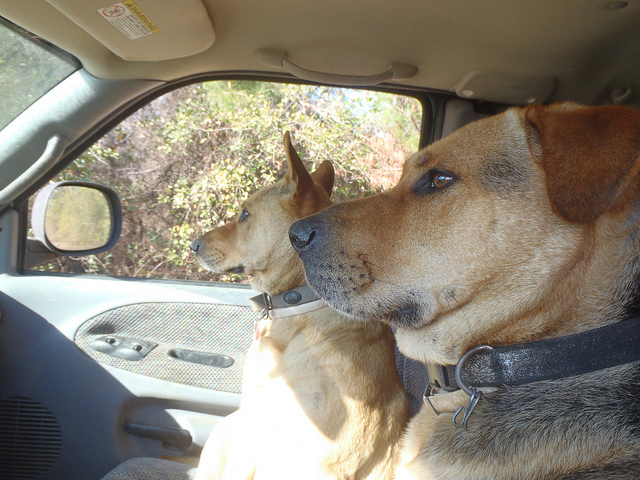

In [32]:
print(train_captions[0])
Image.open(img_name_vector[0])

In [33]:
batch_sizes = {2: 16, 3: 16, 4: 16, 5: 16, 6: 16, 7: 8, 8: 4, 9: 2, 10: 1}
# We adjust the train step accordingly
train_step_ratio = {k: batch_sizes[2] / v for k, v in batch_sizes.items()}

In [34]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    return img

In [35]:
try_img = load_image(img_name_vector[0])

In [36]:
# Get unique images
encode_train = sorted(set(img_name_vector))

# Feel free to change batch_size according to your system configuration
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(
  load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [37]:
caption_dataset = tf.data.Dataset.from_tensor_slices(train_captions)

In [38]:
cap_vector = caption_dataset

In [39]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(img_name_vector, cap_vector):
  img_to_cap_vector[img].append(cap)

# Create training and validation sets using an 80-20 split randomly.
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

img_name_train = []
cap_train = []
for imgt in img_name_train_keys:
  capt_len = len(img_to_cap_vector[imgt])
  img_name_train.extend([imgt] * capt_len)
  cap_train.extend(img_to_cap_vector[imgt])

img_name_val = []
cap_val = []
for imgv in img_name_val_keys:
  capv_len = len(img_to_cap_vector[imgv])
  img_name_val.extend([imgv] * capv_len)
  cap_val.extend(img_to_cap_vector[imgv])

In [40]:
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)

(331298, 331298, 82815, 82815)

In [41]:
img_dataset = tf.data.Dataset.from_tensor_slices(img_name_train)

In [42]:
img_vectors = img_dataset.map(load_image)

In [43]:
cap_dataset = tf.data.Dataset.from_tensor_slices(cap_train)

In [44]:
cap_vector = cap_dataset

In [45]:
for i in cap_vector:
  print(i)
  break

tf.Tensor(b'<start> A row of vespas being driven down an alley. <end>', shape=(), dtype=string)


In [46]:
img_vectors, cap_vector

(<MapDataset element_spec=TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None)>,
 <TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>)

In [47]:
for i in cap_vector:
  print(tf.compat.as_str_any(i.numpy()))
  print(type(tf.compat.as_str_any(i.numpy())))
  break

<start> A row of vespas being driven down an alley. <end>
<class 'str'>


In [48]:
for i in img_vectors:
  print(i.shape)
  break

(476, 640, 3)


In [49]:
def resize_image(res, image):
    # only donwsampling, so use nearest neighbor that is faster to run
    image = tf.image.resize(
        image, (res, res), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image

In [50]:
def create_dataloader(res):
    batch_size = batch_sizes[log2(res)]
    dl = img_vectors.map(partial(resize_image, res), num_parallel_calls=tf.data.AUTOTUNE)
    dl = dl.batch(batch_size, drop_remainder=True).prefetch(1).repeat()
    dl2 = cap_vector.batch(batch_size, drop_remainder=True).prefetch(1).repeat()
    return dl, dl2

In [51]:
def plot_images(images, log2_res, fname=""):
    scales = {2: 0.5, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8}
    scale = scales[log2_res]

    grid_col = min(images.shape[0], int(32 // scale))
    grid_row = 1

    f, axarr = plt.subplots(
        grid_row, grid_col, figsize=(grid_col * scale, grid_row * scale)
    )

    for row in range(grid_row):
        ax = axarr if grid_row == 1 else axarr[row]
        for col in range(grid_col):
            ax[col].imshow(images[row * grid_col + col])
            ax[col].axis("off")
    plt.show()
    if fname:
        f.savefig(fname)

In [52]:
## Training the styleGAN
def train(
    start_res=START_RES,
    target_res=TARGET_RES,
    steps_per_epoch=5000,
    display_images=True,
):
    opt_cfg = {"learning_rate": 1e-3, "beta_1": 0.0, "beta_2": 0.99, "epsilon": 1e-8}

    val_batch_size = 16
    val_z = tf.random.normal((val_batch_size, style_gan.z_dim))
    val_noise = style_gan.generate_noise(val_batch_size)

    start_res_log2 = int(np.log2(start_res))
    target_res_log2 = int(np.log2(target_res))

    for res_log2 in range(start_res_log2, target_res_log2 + 1):
        res = 2 ** res_log2
        for phase in ["TRANSITION", "STABLE"]:
            if res == start_res and phase == "TRANSITION":
                continue

            train_dl, caption_dl = create_dataloader(res)
            dataset = tf.data.Dataset.zip((train_dl, caption_dl))

            steps = int(train_step_ratio[res_log2] * steps_per_epoch)

            style_gan.compile(
                d_optimizer=tf.keras.optimizers.Adam(**opt_cfg),
                g_optimizer=tf.keras.optimizers.Adam(**opt_cfg),
                loss_weights={"gradient_penalty": 10, "drift": 0.001},
                steps_per_epoch=steps,
                res=res,
                phase=phase, 
                run_eagerly=True,
            )

            prefix = f"res_{res}x{res}_{style_gan.phase}"

            ckpt_cb = keras.callbacks.ModelCheckpoint(
                f"checkpoints/stylegan_{res}x{res}.ckpt",
                save_weights_only=True,
                verbose=0,
            )
            print(phase)
            style_gan.fit(
                dataset, epochs=1, steps_per_epoch=steps, callbacks=[ckpt_cb]
            )

            if display_images:
                images = style_gan({"z": val_z, "noise": val_noise, "alpha": 1.0, "v": "A bird"})
                plot_images(images, res_log2)

In [62]:
tf.config.run_functions_eagerly(True)
train(start_res=4, target_res=32, steps_per_epoch=1, display_images=True)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/data/ops/structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


STABLE
real_text: [b'<start> A row of vespas being driven down an alley. <end>'
 b'<start> A group of people going through a narrow road on scooters.  <end>'
 b'<start> People standing and riding down an alley on mopeds. <end>'
 b'<start> Men driving down a crowded city shopping district. <end>'
 b'<start> A line of bikers make their way through the narrow street between buildings, and past pedestrians. <end>'
 b'<start> a car passing a stop sign that says "whoa" <end>'
 b'<start> a car that is parked next to a stop sign <end>'
 b'<start> A small cute sign saying whoa by a small road. <end>'
 b'<start> there is a sign that has whoa on it and there as a truck behind it <end>'
 b'<start> A vehicle on a road in the country  <end>'
 b'<start> there is a male biker sitting next to a cow that is laying down <end>'
 b'<start> A Swiss biker in full outfit sits in an Alpine mountain meadow next to a cow in a scarf.  <end>'
 b'<start> A man squatting in a field next to a cow. <end>'
 b'<start> C

TypeError: ignored

In [ ]:
batch_size = 2
images = style_gan({"v": "Bird"})
plot_images(images, 5)

In [ ]:
plt.imshow(images[0])

In [ ]:
z = tf.random.normal((batch_size, style_gan.z_dim))
const_input = tf.ones(tuple([batch_size] + list(style_gan.g_input_shape)))
noise = style_gan.generate_noise(batch_size)
w = style_gan.mapping(z)
v = text2PCA("This is a bird")
v = tf.expand_dims(v, axis=0)
style_gan.generator([const_input, w, noise, 1.0, v])